# CSQA Answer-Choice Tuned Lens Analysis

This notebook analyzes CommonsenseQA in a single methodology:

- tuned-lens style preparation first
- only the constrained A-E answer-choice decision space
- layerwise trace analysis after the tuned readout is ready

The notebook is organized as:

1. data and model setup
2. hidden-state cache extraction
3. tuned-lens training
4. direct-vs-tuned summary
5. tuned layerwise analysis of entropy, logit gap, stability, and agreement


In [6]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer

from src.data.load_csqa import load_csqa

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

## Configuration

These defaults are set for a serious run rather than a tiny smoke test. Reduce TRAIN_LIMIT or EVAL_LIMIT if you want a faster pass first.


In [7]:
MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"
TRAIN_SPLIT = "train"
EVAL_SPLIT = "validation"
TRAIN_LIMIT = 4096
EVAL_LIMIT = None
MAX_SEQ_LEN = 384
EXTRACT_BATCH_SIZE = 2
TUNED_LENS_BATCH_SIZE = 64
TUNED_LENS_EPOCHS = 8
TUNED_LENS_LR = 5e-4
TUNED_LENS_WEIGHT_DECAY = 1e-5
SEED = 42
USE_BFLOAT16_IF_AVAILABLE = True
ANSWER_CHOICE_ENTROPY_SATURATION_THRESHOLD = 0.25
ANSWER_CHOICE_GAP_STABILITY_THRESHOLD = 3.0


## Data And Model Setup

The tuned lens is trained on cached hidden states. The base model itself stays frozen.


In [8]:
torch.manual_seed(SEED)
np.random.seed(SEED)

LETTERS = ["A", "B", "C", "D", "E"]

train_rows = load_csqa(split=TRAIN_SPLIT, limit=TRAIN_LIMIT).copy()
eval_rows = load_csqa(split=EVAL_SPLIT, limit=EVAL_LIMIT).copy()

for frame in [train_rows, eval_rows]:
    frame["n_choices"] = frame["csqa_choices"].map(len)
    frame["prompt_len_chars"] = frame["text"].str.len()
    assert frame["n_choices"].eq(5).all(), "Expected 5 choices for every CSQA row."

if torch.cuda.is_available():
    if USE_BFLOAT16_IF_AVAILABLE and torch.cuda.is_bf16_supported():
        model_dtype = torch.bfloat16
    else:
        model_dtype = torch.float16
    device_map = "auto"
else:
    model_dtype = torch.float32
    device_map = None

tok = AutoTokenizer.from_pretrained(MODEL_ID)
if tok.pad_token is None:
    tok.pad_token = tok.eos_token
tok.padding_side = "left"

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=model_dtype,
    device_map=device_map,
    attn_implementation="eager",
)
model.eval()


def build_answer_token_ids(tok):
    out = {}
    for letter in LETTERS:
        ids = tok(" " + letter, add_special_tokens=False)["input_ids"]
        if len(ids) != 1:
            raise ValueError(f"Answer token '{letter}' is not single-token: {ids}")
        out[letter] = int(ids[0])
    return out


answer_token_ids = build_answer_token_ids(tok)
answer_ids = [answer_token_ids[l] for l in LETTERS]
answer_id_tensor = torch.tensor(answer_ids, dtype=torch.long)

display(train_rows[["example_id", "answerKey", "prompt_len_chars"]].head())
print("train rows:", len(train_rows))
print("eval rows:", len(eval_rows))
print("answer token ids:", answer_token_ids)


Loading weights: 100%|██████████| 434/434 [00:00<00:00, 834.32it/s]


,example_id,answerKey,prompt_len_chars
0,42ed410d54eae473eb4578d8550259ed,A,200
1,a7059f15c9a41e642c05358ee3bfdad5,B,157
2,ae67f1af6b3e31ab97be57aa2519b565,A,166
3,bbc3ddd9f2ef318ee7dd8c728da8b5b9,D,154
4,b8ede90d3c3d058c817d5ce9beb2227f,C,170


train rows: 4096
eval rows: 1221
answer token ids: {'A': 362, 'B': 425, 'C': 356, 'D': 422, 'E': 468}


## Helper Functions

These helpers locate the model's final normalization, encode prompts to the answer position, and define the trace statistics used later in the notebook.


In [9]:
def get_final_norm_module(model):
    candidates = [
        "model.norm",
        "model.final_layernorm",
        "transformer.ln_f",
        "gpt_neox.final_layer_norm",
    ]
    for path in candidates:
        cur = model
        ok = True
        for part in path.split("."):
            if not hasattr(cur, part):
                ok = False
                break
            cur = getattr(cur, part)
        if ok:
            return cur
    return None


def encode_prompts(texts, tok, max_seq_len):
    batch = tok(
        list(texts),
        add_special_tokens=False,
        truncation=True,
        max_length=max_seq_len,
        padding=True,
        return_tensors="pt",
    )
    pos = []
    for mask in batch["attention_mask"]:
        nz = torch.nonzero(mask, as_tuple=False).view(-1)
        pos.append(int(nz[-1].item()))
    batch["decision_pos"] = torch.tensor(pos, dtype=torch.long)
    return batch


def first_true(mask):
    idx = np.flatnonzero(np.asarray(mask, dtype=bool))
    return float(idx[0]) if len(idx) else np.nan


def first_stable(mask):
    mask = np.asarray(mask, dtype=bool)
    for i in range(len(mask)):
        if mask[i] and mask[i:].all():
            return float(i)
    return np.nan


def first_numeric_stable(values):
    values = np.asarray(values)
    for i in range(len(values)):
        if np.all(values[i:] == values[i]):
            return float(i)
    return np.nan


def first_threshold_crossing(values, threshold, direction="le"):
    values = np.asarray(values, dtype=float)
    if direction == "le":
        idx = np.flatnonzero(values <= threshold)
    elif direction == "ge":
        idx = np.flatnonzero(values >= threshold)
    else:
        raise ValueError(direction)
    return float(idx[0]) if len(idx) else np.nan


def first_threshold_stable(values, threshold, direction="le"):
    values = np.asarray(values, dtype=float)
    for i in range(len(values)):
        tail = values[i:]
        if direction == "le" and np.all(tail <= threshold):
            return float(i)
        if direction == "ge" and np.all(tail >= threshold):
            return float(i)
    return np.nan


def rank_bucket(rank):
    rank = int(rank)
    if rank == 1:
        return "rank1_correct"
    if rank == 2:
        return "rank2_near_miss"
    return "rank3plus_hard"


final_norm = get_final_norm_module(model)
lm_head_weight = model.lm_head.weight.detach()
answer_choice_weight = lm_head_weight[answer_id_tensor.to(lm_head_weight.device)].float()
log_answer_choice_count = float(np.log(len(LETTERS)))

probe_cpu = encode_prompts(eval_rows["text"].head(1), tok, MAX_SEQ_LEN)
probe_pos = int(probe_cpu["decision_pos"][0].item())
probe = {k: v.to(model.device) for k, v in probe_cpu.items() if k != "decision_pos"}
with torch.no_grad():
    probe_out = model(**probe, output_hidden_states=True, return_dict=True, use_cache=False)

hidden_probe = probe_out.hidden_states
L_plus_1 = len(hidden_probe)
L = L_plus_1 - 1
hidden_size = int(hidden_probe[-1].shape[-1])

target_choice_logits = probe_out.logits[0, probe_pos, answer_id_tensor.to(probe_out.logits.device)].float().detach().cpu()
raw_last = hidden_probe[-1][0, probe_pos].float()
raw_logits = torch.mv(answer_choice_weight.cpu(), raw_last.detach().cpu())

if final_norm is not None:
    normed_last = final_norm(raw_last.unsqueeze(0)).squeeze(0)
    normed_logits = torch.mv(answer_choice_weight.cpu(), normed_last.detach().cpu())
    raw_err = torch.mean(torch.abs(raw_logits - target_choice_logits)).item()
    normed_err = torch.mean(torch.abs(normed_logits - target_choice_logits)).item()
    LAST_LAYER_NEEDS_NORM = bool(normed_err < raw_err)
else:
    LAST_LAYER_NEEDS_NORM = False


def maybe_apply_final_norm_gpu(h, layer_idx):
    if final_norm is None:
        return h
    if layer_idx < L:
        return final_norm(h)
    if LAST_LAYER_NEEDS_NORM:
        return final_norm(h)
    return h


import copy
final_norm_cpu = copy.deepcopy(final_norm).cpu().eval() if final_norm is not None else None



def maybe_apply_final_norm_cpu(h, layer_idx):
    if final_norm_cpu is None:
        return h
    if layer_idx < L:
        return final_norm_cpu(h)
    if LAST_LAYER_NEEDS_NORM:
        return final_norm_cpu(h)
    return h


print("L+1:", L_plus_1)
print("hidden_size:", hidden_size)
print("last layer needs final norm:", LAST_LAYER_NEEDS_NORM)


L+1: 37
hidden_size: 2048
last layer needs final norm: False


## Hidden-State Cache Extraction

We cache only the decision-position hidden states and the final answer-choice distribution. That is enough for tuned-lens training and keeps the notebook focused on the A-E decision space.


In [10]:
def extract_split_cache(frame, desc):
    hidden_blocks = []
    final_choice_prob_blocks = []
    true_choice_idx_blocks = []

    for start in tqdm(range(0, len(frame), EXTRACT_BATCH_SIZE), total=int(math.ceil(len(frame) / EXTRACT_BATCH_SIZE)), desc=desc):
        batch_df = frame.iloc[start:start + EXTRACT_BATCH_SIZE].reset_index(drop=True)
        batch_cpu = encode_prompts(batch_df["text"], tok, MAX_SEQ_LEN)
        decision_pos = batch_cpu.pop("decision_pos")
        batch = {k: v.to(model.device) for k, v in batch_cpu.items()}
        decision_pos = decision_pos.to(model.device)

        with torch.no_grad():
            out = model(**batch, output_hidden_states=True, return_dict=True, use_cache=False)

        hidden_states = out.hidden_states
        per_layer_hidden = []
        for li in range(L_plus_1):
            h = hidden_states[li][torch.arange(hidden_states[li].shape[0], device=decision_pos.device), decision_pos].float()
            per_layer_hidden.append(h.detach().cpu())

        final_raw = hidden_states[-1][torch.arange(hidden_states[-1].shape[0], device=decision_pos.device), decision_pos].float()
        final_readout = maybe_apply_final_norm_gpu(final_raw, L)
        final_choice_logits = torch.matmul(final_readout, answer_choice_weight.T)
        final_choice_probs = torch.softmax(final_choice_logits, dim=-1).detach().cpu()
        true_choice_idx = torch.tensor([LETTERS.index(str(x)) for x in batch_df["answerKey"].tolist()], dtype=torch.long)

        hidden_blocks.append(torch.stack(per_layer_hidden, dim=1))
        final_choice_prob_blocks.append(final_choice_probs)
        true_choice_idx_blocks.append(true_choice_idx)

    return {
        "hidden": torch.cat(hidden_blocks, dim=0),
        "final_choice_probs": torch.cat(final_choice_prob_blocks, dim=0),
        "true_choice_idx": torch.cat(true_choice_idx_blocks, dim=0),
        "answerKey": frame["answerKey"].astype(str).tolist(),
        "example_id": frame["example_id"].tolist(),
    }


train_cache = extract_split_cache(train_rows, "extract train hidden cache")
eval_cache = extract_split_cache(eval_rows, "extract eval hidden cache")

print("train hidden cache:", tuple(train_cache["hidden"].shape))
print("eval hidden cache:", tuple(eval_cache["hidden"].shape))


extract eval hidden cache: 100%|██████████| 611/611 [00:25<00:00, 23.83it/s]


train hidden cache: (4096, 37, 2048)
eval hidden cache: (1221, 37, 2048)


## Tuned Lens Preparation

Each layer gets a small affine translator trained to reproduce the model's final A-E answer-choice distribution. After this section, the notebook uses the tuned readout for the rest of the analysis.


In [11]:
class AffineTranslator(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.linear = nn.Linear(hidden_size, hidden_size)

    def forward(self, x):
        return self.linear(x)


train_device = model.device if torch.cuda.is_available() else torch.device("cpu")
answer_choice_weight_train = answer_choice_weight.to(train_device).float()
teacher_choice_probs_train = train_cache["final_choice_probs"].float()

lenses = []
train_history_rows = []

for li in range(L_plus_1):
    if li == L:
        lenses.append(None)
        continue

    lens = AffineTranslator(hidden_size).to(train_device)
    optimizer = torch.optim.AdamW(lens.parameters(), lr=TUNED_LENS_LR, weight_decay=TUNED_LENS_WEIGHT_DECAY)

    ds = TensorDataset(train_cache["hidden"][:, li, :].float(), teacher_choice_probs_train)
    dl = DataLoader(ds, batch_size=TUNED_LENS_BATCH_SIZE, shuffle=True)

    for epoch in range(1, TUNED_LENS_EPOCHS + 1):
        batch_losses = []
        lens.train()
        for xb, teacher_probs_b in dl:
            xb = xb.to(train_device)
            teacher_probs_b = teacher_probs_b.to(train_device)
            pred_readout = lens(xb)
            pred_choice_logits = torch.matmul(pred_readout, answer_choice_weight_train.T)
            pred_log_probs = torch.log_softmax(pred_choice_logits, dim=-1)
            loss = F.kl_div(pred_log_probs, teacher_probs_b, reduction="batchmean")
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
            batch_losses.append(float(loss.item()))

        train_history_rows.append(
            {
                "layer": li,
                "epoch": epoch,
                "mean_kl_loss": float(np.mean(batch_losses)),
            }
        )

    lens.eval()
    lenses.append(lens.cpu())

train_history_df = pd.DataFrame(train_history_rows)
display(train_history_df.head())

,layer,epoch,mean_kl_loss
0,0,1,1.565373
1,0,2,1.556539
2,0,3,1.556813
3,0,4,1.558229
4,0,5,1.556542


## Tuned Lens Training Summary

Lower KL means the layer translator is matching the model's final A-E distribution more closely.


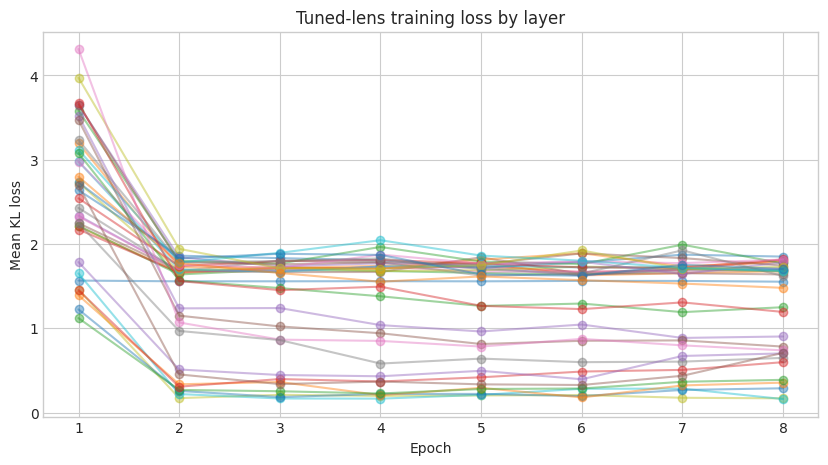

,layer,final_epoch_mean_kl_loss
7,0,1.552075
15,1,1.676485
23,2,1.690215
31,3,1.806904
39,4,1.707319
47,5,1.638373
55,6,1.694793
63,7,1.672693
71,8,1.675038
79,9,1.685432


In [12]:
plt.figure(figsize=(10, 5))
for li, g in train_history_df.groupby("layer"):
    plt.plot(g["epoch"], g["mean_kl_loss"], marker="o", alpha=0.45)
plt.xlabel("Epoch")
plt.ylabel("Mean KL loss")
plt.title("Tuned-lens training loss by layer")
plt.show()

training_summary = (
    train_history_df.sort_values(["layer", "epoch"])
    .groupby("layer")
    .tail(1)
    [["layer", "mean_kl_loss"]]
    .rename(columns={"mean_kl_loss": "final_epoch_mean_kl_loss"})
)
display(training_summary.head(10).round(6))

## Direct Vs Tuned Summary

This is a compact sanity check before the trace analysis.

The direct readout uses the raw layer state plus the model's output mapping.
The tuned readout uses the trained layer translators.

After this point, the notebook proceeds with the tuned readout only.


In [13]:
def evaluate_method(cache, method_name):
    n = cache["hidden"].shape[0]
    true_choice_idx = cache["true_choice_idx"].numpy()
    final_choice_probs = cache["final_choice_probs"].numpy().astype(np.float32)

    answer_choice_entropy = np.zeros((n, L_plus_1), dtype=np.float32)
    answer_choice_entropy_norm = np.zeros((n, L_plus_1), dtype=np.float32)
    answer_choice_gap = np.zeros((n, L_plus_1), dtype=np.float32)
    true_answer_prob = np.zeros((n, L_plus_1), dtype=np.float32)
    true_answer_rank = np.zeros((n, L_plus_1), dtype=np.float32)
    choice_kl_to_final = np.zeros((n, L_plus_1), dtype=np.float32)
    predicted_choice_index = np.zeros((n, L_plus_1), dtype=np.int64)

    for li in tqdm(range(L_plus_1), desc=f"evaluate {method_name}"):
        batch_logits = []
        for start in range(0, n, TUNED_LENS_BATCH_SIZE):
            xb = cache["hidden"][start:start + TUNED_LENS_BATCH_SIZE, li, :].float()

            if method_name == "direct":
                readout = maybe_apply_final_norm_cpu(xb, li)
            elif method_name == "tuned":
                if li == L:
                    readout = maybe_apply_final_norm_cpu(xb, li)
                else:
                    readout = lenses[li](xb)
            else:
                raise ValueError(method_name)

            logits = torch.matmul(readout, answer_choice_weight.float().cpu().T)
            batch_logits.append(logits.detach().cpu())

        choice_logits = torch.cat(batch_logits, dim=0).numpy().astype(np.float32)
        choice_log_probs = choice_logits - np.logaddexp.reduce(choice_logits, axis=1, keepdims=True)
        choice_probs = np.exp(choice_log_probs)

        answer_choice_entropy[:, li] = -(choice_probs * choice_log_probs).sum(axis=1)
        answer_choice_entropy_norm[:, li] = answer_choice_entropy[:, li] / log_answer_choice_count
        sorted_choice = np.sort(choice_logits, axis=1)[:, ::-1]
        answer_choice_gap[:, li] = sorted_choice[:, 0] - sorted_choice[:, 1]
        predicted_choice_index[:, li] = np.argmax(choice_logits, axis=1)
        true_answer_prob[:, li] = choice_probs[np.arange(n), true_choice_idx]
        true_answer_rank[:, li] = 1 + (choice_logits > choice_logits[np.arange(n), true_choice_idx][:, None]).sum(axis=1)
        choice_kl_to_final[:, li] = np.sum(
            final_choice_probs * (np.log(np.clip(final_choice_probs, 1e-12, None)) - choice_log_probs),
            axis=1,
        )

    rows = []
    for i in range(n):
        pred_curve = predicted_choice_index[i]
        final_pred_idx = int(pred_curve[-1])
        final_pred_letter = LETTERS[final_pred_idx]
        agreement_with_final_curve = (pred_curve == final_pred_idx)
        final_rank = int(true_answer_rank[i, -1])

        rows.append(
            {
                "method": method_name,
                "example_id": cache["example_id"][i],
                "answerKey": cache["answerKey"][i],
                "final_answer_choice_prediction": final_pred_letter,
                "final_answer_choice_is_correct": bool(final_pred_letter == cache["answerKey"][i]),
                "answer_choice_rank_bucket": rank_bucket(final_rank),
                "final_answer_choice_true_rank": final_rank,
                "answer_choice_hit_at_2": bool(final_rank <= 2),
                "answer_choice_hit_at_3": bool(final_rank <= 3),
                "final_answer_choice_entropy_normalized": float(answer_choice_entropy_norm[i, -1]),
                "final_answer_choice_top1_top2_logit_gap": float(answer_choice_gap[i, -1]),
                "final_true_answer_probability_within_choices": float(true_answer_prob[i, -1]),
                "mean_choice_kl_to_final": float(choice_kl_to_final[i, :-1].mean()),
                "mean_layerwise_hit_at_1": float((true_answer_rank[i] <= 1).mean()),
                "mean_layerwise_hit_at_2": float((true_answer_rank[i] <= 2).mean()),
                "mean_layerwise_hit_at_3": float((true_answer_rank[i] <= 3).mean()),
                "answer_choice_prediction_flip_count": int(np.sum(pred_curve[1:] != pred_curve[:-1])),
                "first_answer_choice_prediction_stable_layer": first_numeric_stable(pred_curve),
                "first_low_answer_choice_entropy_layer": first_threshold_crossing(answer_choice_entropy_norm[i], ANSWER_CHOICE_ENTROPY_SATURATION_THRESHOLD, direction="le"),
                "answer_choice_gap_stable_layer": first_threshold_stable(answer_choice_gap[i], ANSWER_CHOICE_GAP_STABILITY_THRESHOLD, direction="ge"),
                "true_answer_rank_stable_layer": first_numeric_stable(true_answer_rank[i]),
                "first_answer_choice_agreement_with_final_layer": first_true(agreement_with_final_curve),
                "stable_answer_choice_agreement_with_final_layer": first_stable(agreement_with_final_curve),
                "answer_choice_entropy_curve": answer_choice_entropy[i].copy(),
                "answer_choice_entropy_normalized_curve": answer_choice_entropy_norm[i].copy(),
                "answer_choice_top1_top2_logit_gap_curve": answer_choice_gap[i].copy(),
                "true_answer_probability_within_choices_curve": true_answer_prob[i].copy(),
                "true_answer_rank_within_choices_curve": true_answer_rank[i].copy(),
                "choice_kl_to_final_curve": choice_kl_to_final[i].copy(),
                "answer_choice_prediction_index_curve": pred_curve.copy(),
                "answer_choice_prediction_agreement_with_final_curve": agreement_with_final_curve.astype(np.float32),
            }
        )

    return pd.DataFrame(rows)


direct_df = evaluate_method(eval_cache, "direct")
tuned_df = evaluate_method(eval_cache, "tuned")

summary_rows = []
for method_name, frame in [("direct", direct_df), ("tuned", tuned_df)]:
    summary_rows.append(
        {
            "method": method_name,
            "mean_choice_kl_to_final": float(frame["mean_choice_kl_to_final"].mean()),
            "mean_layerwise_hit_at_1": float(frame["mean_layerwise_hit_at_1"].mean()),
            "mean_layerwise_hit_at_2": float(frame["mean_layerwise_hit_at_2"].mean()),
            "mean_layerwise_hit_at_3": float(frame["mean_layerwise_hit_at_3"].mean()),
            "final_hit_at_1": float(frame["final_answer_choice_is_correct"].mean()),
            "final_hit_at_2": float(frame["answer_choice_hit_at_2"].mean()),
            "final_hit_at_3": float(frame["answer_choice_hit_at_3"].mean()),
        }
    )

direct_vs_tuned_summary = pd.DataFrame(summary_rows)
display(direct_vs_tuned_summary.round(4))

evaluate tuned: 100%|██████████| 37/37 [00:02<00:00, 13.26it/s]


,method,mean_choice_kl_to_final,mean_layerwise_hit_at_1,mean_layerwise_hit_at_2,mean_layerwise_hit_at_3,final_hit_at_1,final_hit_at_2,final_hit_at_3
0,direct,2.2369,0.3204,0.5017,0.6682,0.8026,0.9345,0.9697
1,tuned,1.3451,0.4148,0.5997,0.7456,0.8026,0.9345,0.9697


## Tuned Trace Analysis Setup

From here on, the notebook uses only the tuned readout.
The final buckets are still:

- rank1_correct
- rank2_near_miss
- rank3plus_hard


In [14]:
analysis_df = tuned_df.copy()
bucket_order = ["rank1_correct", "rank2_near_miss", "rank3plus_hard"]
bucket_colors = {
    "rank1_correct": "#2a9d8f",
    "rank2_near_miss": "#e9c46a",
    "rank3plus_hard": "#e76f51",
}

display(
    pd.DataFrame(
        {
            "count": analysis_df["answer_choice_rank_bucket"].value_counts().reindex(bucket_order),
            "share": analysis_df["answer_choice_rank_bucket"].value_counts(normalize=True).reindex(bucket_order),
        }
    ).round(4)
)

,count,share
answer_choice_rank_bucket,,
rank1_correct,980,0.8026
rank2_near_miss,161,0.1319
rank3plus_hard,80,0.0655


## Final-Layer Summary By Bucket

This table shows how the final tuned readout differs between correct, near-miss, and hard-miss examples.


In [15]:
summary_cols = [
    "final_answer_choice_entropy_normalized",
    "final_answer_choice_top1_top2_logit_gap",
    "final_true_answer_probability_within_choices",
    "answer_choice_prediction_flip_count",
    "first_answer_choice_prediction_stable_layer",
    "first_answer_choice_agreement_with_final_layer",
    "stable_answer_choice_agreement_with_final_layer",
]

display(
    analysis_df.groupby("answer_choice_rank_bucket")[summary_cols]
    .agg(["mean", "median", "std"])
    .round(4)
)

final_answer_choice_entropy_normalized                 final_answer_choice_top1_top2_logit_gap                   \
                                                            mean  median     std                                    mean   median     std   
answer_choice_rank_bucket                                                                                                                   
rank1_correct                                             0.0223  0.0001  0.0769                                 10.7519  11.8922  3.8782   
rank2_near_miss                                           0.0975  0.0143  0.1482                                  6.2351   5.7513  3.9723   
rank3plus_hard                                            0.1260  0.0110  0.1863                                  6.3280   6.3811  4.4416   

                          final_true_answer_probability_within_choices                 answer_choice_prediction_flip_count                 \
                                                                  mean  median     std                                mean median     std   
answer_choice_rank_bucket                                                                                                                   
rank1_correct                                                   0.9863  1.0000  0.0588                             19.4133   19.0  2.1405   
rank2_near_miss                                                 0.0600  0.0032  0.1113                             20.6646   20.0  2.6147   
rank3plus_hard                                                  0.0049  0.0000  0.0206                             21.3000   21.0  2.5970   

                          first_answer_choice_prediction_stable_layer                first_answer_choice_agreement_with_final_layer                 \
                                                                 mean median     std                                           mean median     std   
answer_choice_rank_bucket                                                                                                                            
rank1_correct                                                 25.5265   25.0  3.0672                                         4.1857    2.0  4.5965   
rank2_near_miss                                               27.8634   27.0  3.8479                                         4.3789    4.0  5.1587   
rank3plus_hard                                                28.5750   28.0  4.3684                                         4.0125    2.0  5.2591   

                          stable_answer_choice_agreement_with_final_layer                 
                                                                     mean median     std  
answer_choice_rank_bucket                                                                 
rank1_correct                                                     25.5265   25.0  3.0672  
rank2_near_miss                                                   27.8634   27.0  3.8479  
rank3plus_hard                                                    28.5750   28.0  4.3684

## Entropy Over Layers

This section tracks uncertainty inside the A-E answer-choice space only.
A lower curve means the model is becoming more committed among the five answer options.


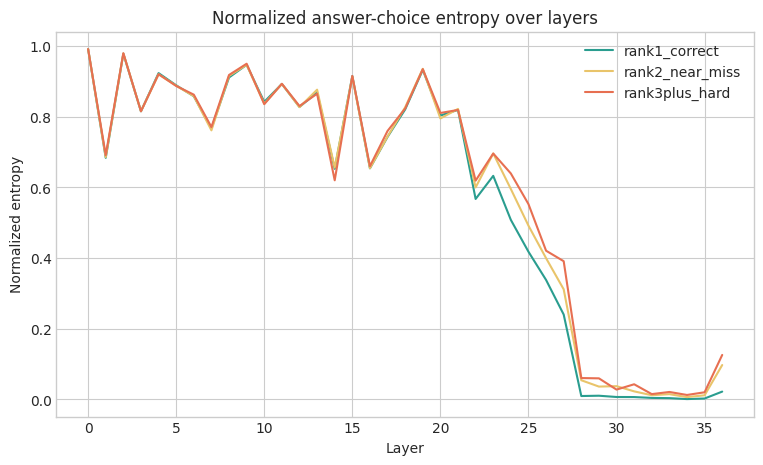

In [16]:
layers = np.arange(L_plus_1)


def stack_curve(col):
    return np.stack(analysis_df[col].to_list(), axis=0)


def mean_curve(col, bucket):
    mat = stack_curve(col)
    mask = analysis_df["answer_choice_rank_bucket"].eq(bucket).to_numpy()
    return mat[mask].mean(axis=0)

entropy_curve_col = "answer_choice_entropy_normalized_curve"

plt.figure(figsize=(9, 5))
for bucket in bucket_order:
    plt.plot(layers, mean_curve(entropy_curve_col, bucket), label=bucket, color=bucket_colors[bucket])
plt.xlabel("Layer")
plt.ylabel("Normalized entropy")
plt.title("Normalized answer-choice entropy over layers")
plt.legend()
plt.show()

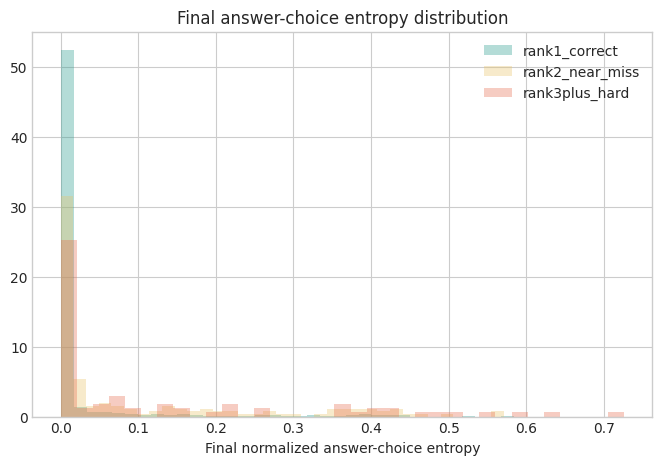

In [17]:
plt.figure(figsize=(8, 5))
for bucket in bucket_order:
    vals = pd.to_numeric(
        analysis_df.loc[analysis_df["answer_choice_rank_bucket"].eq(bucket), "final_answer_choice_entropy_normalized"],
        errors="coerce",
    ).dropna()
    plt.hist(vals, bins=35, density=True, alpha=0.35, label=bucket, color=bucket_colors[bucket])
plt.xlabel("Final normalized answer-choice entropy")
plt.title("Final answer-choice entropy distribution")
plt.legend()
plt.show()

## Logit Gap Over Layers

This section tracks the gap between the strongest and second-strongest answer choice.
A larger gap means the model is separating one option more clearly from the runner-up.


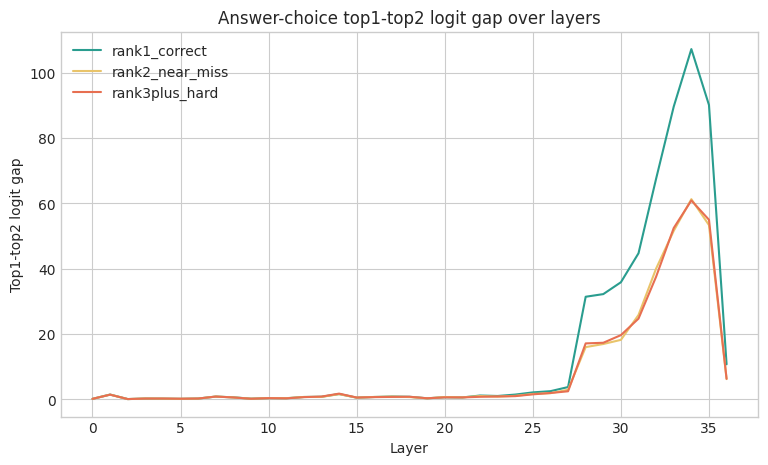

In [18]:
gap_curve_col = "answer_choice_top1_top2_logit_gap_curve"

plt.figure(figsize=(9, 5))
for bucket in bucket_order:
    plt.plot(layers, mean_curve(gap_curve_col, bucket), label=bucket, color=bucket_colors[bucket])
plt.xlabel("Layer")
plt.ylabel("Top1-top2 logit gap")
plt.title("Answer-choice top1-top2 logit gap over layers")
plt.legend()
plt.show()


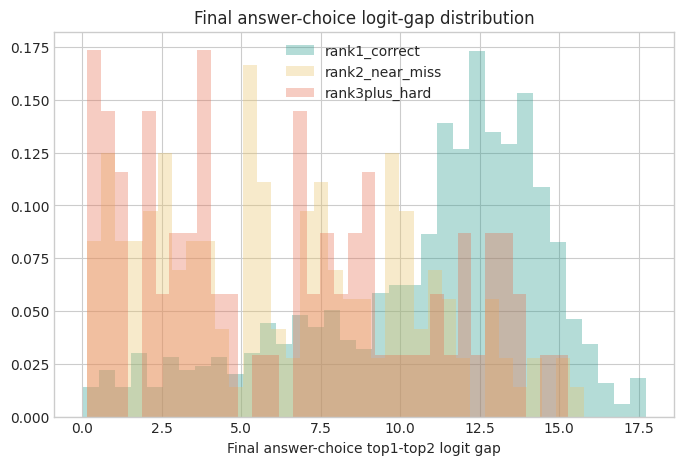

In [19]:
plt.figure(figsize=(8, 5))
for bucket in bucket_order:
    vals = pd.to_numeric(
        analysis_df.loc[analysis_df["answer_choice_rank_bucket"].eq(bucket), "final_answer_choice_top1_top2_logit_gap"],
        errors="coerce",
    ).dropna()
    plt.hist(vals, bins=35, density=True, alpha=0.35, label=bucket, color=bucket_colors[bucket])
plt.xlabel("Final answer-choice top1-top2 logit gap")
plt.title("Final answer-choice logit-gap distribution")
plt.legend()
plt.show()

## Stability Over Layers

This section asks whether the A-E prediction keeps moving or settles early.

The main observable metrics are:

- answer_choice_prediction_flip_count
- first_answer_choice_prediction_stable_layer

A smaller number of flips and an earlier stable layer indicate a more settled decision trajectory.


In [20]:
stability_cols = [
    "answer_choice_prediction_flip_count",
    "first_answer_choice_prediction_stable_layer",
    "first_low_answer_choice_entropy_layer",
    "answer_choice_gap_stable_layer",
]

display(
    analysis_df.groupby("answer_choice_rank_bucket")[stability_cols]
    .agg(["mean", "median", "std"])
    .round(4)
)

answer_choice_prediction_flip_count                first_answer_choice_prediction_stable_layer                first_low_answer_choice_entropy_layer  \
                                                         mean median     std                                        mean median     std                                  mean   
answer_choice_rank_bucket                                                                                                                                                       
rank1_correct                                         19.4133   19.0  2.1405                                     25.5265   25.0  3.0672                               25.8612   
rank2_near_miss                                       20.6646   20.0  2.6147                                     27.8634   27.0  3.8479                               26.6149   
rank3plus_hard                                        21.3000   21.0  2.5970                                     28.5750   28.0  4.3684                               27.0875   

                                         answer_choice_gap_stable_layer                 
                          median     std                           mean median     std  
answer_choice_rank_bucket                                                               
rank1_correct               26.0  1.9359                        27.0272   27.0  1.4894  
rank2_near_miss             27.0  1.8475                        27.5965   28.0  1.6655  
rank3plus_hard              28.0  1.6702                        27.8909   28.0  1.6852

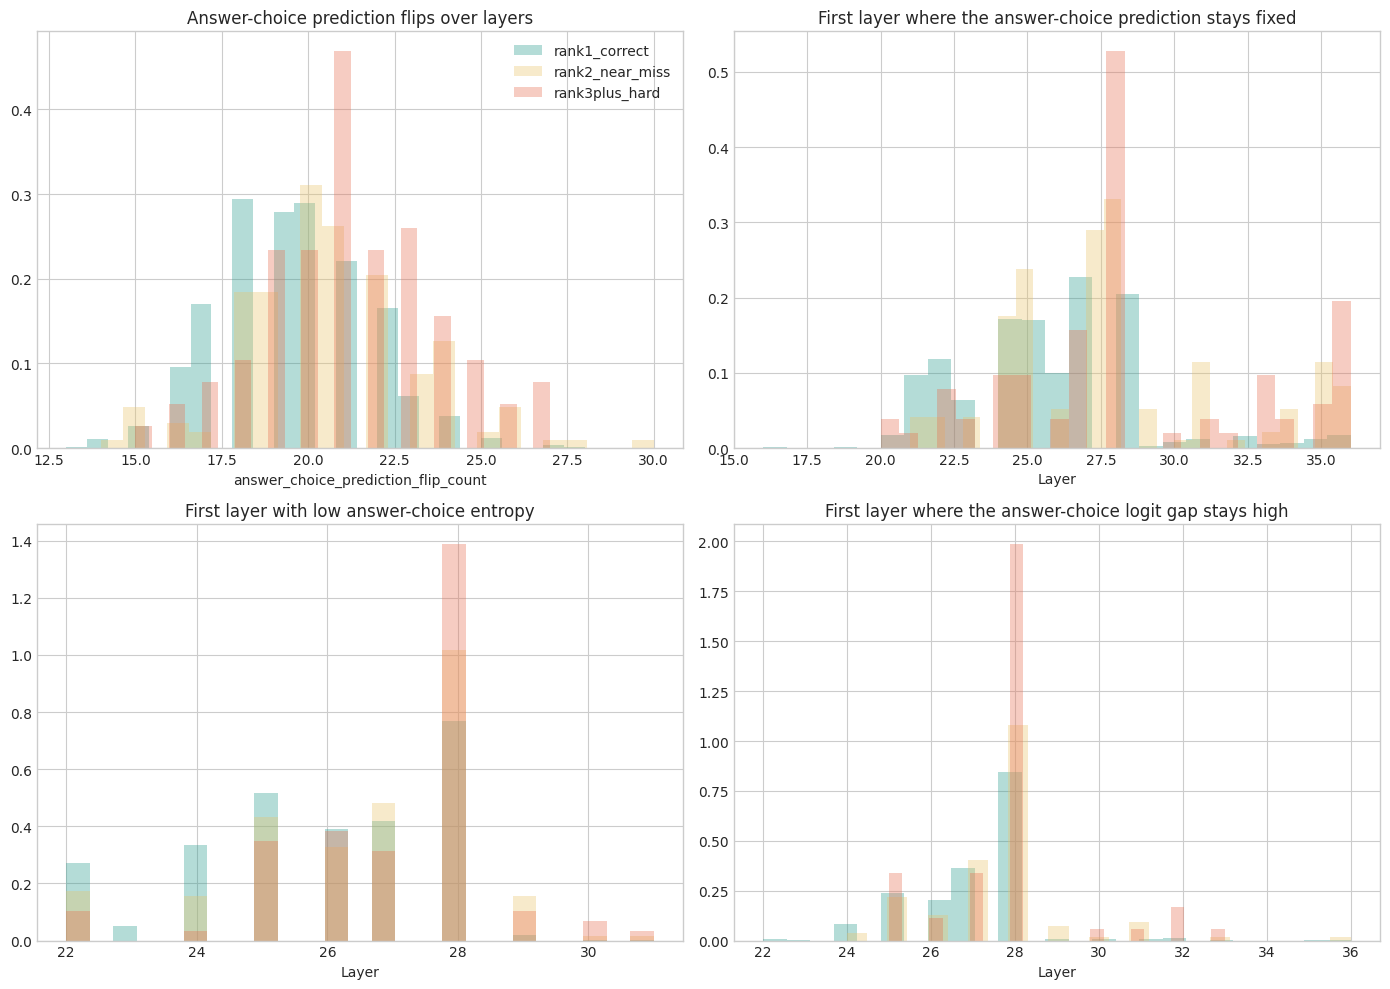

In [21]:
stability_titles = {
    "answer_choice_prediction_flip_count": "Answer-choice prediction flips over layers",
    "first_answer_choice_prediction_stable_layer": "First layer where the answer-choice prediction stays fixed",
    "first_low_answer_choice_entropy_layer": "First layer with low answer-choice entropy",
    "answer_choice_gap_stable_layer": "First layer where the answer-choice logit gap stays high",
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, col in zip(axes, stability_cols):
    for bucket in bucket_order:
        vals = pd.to_numeric(
            analysis_df.loc[analysis_df["answer_choice_rank_bucket"].eq(bucket), col],
            errors="coerce",
        ).dropna()
        ax.hist(vals, bins=25, density=True, alpha=0.35, color=bucket_colors[bucket], label=bucket)
    ax.set_title(stability_titles[col])
    ax.set_xlabel("Layer" if "layer" in col else col)

axes[0].legend()
plt.tight_layout()
plt.show()


## Agreement With The Final Prediction

This section measures when a layer already predicts the same A-E answer as the final tuned readout.

These are post-prediction validation features. They do not use the ground-truth answer.


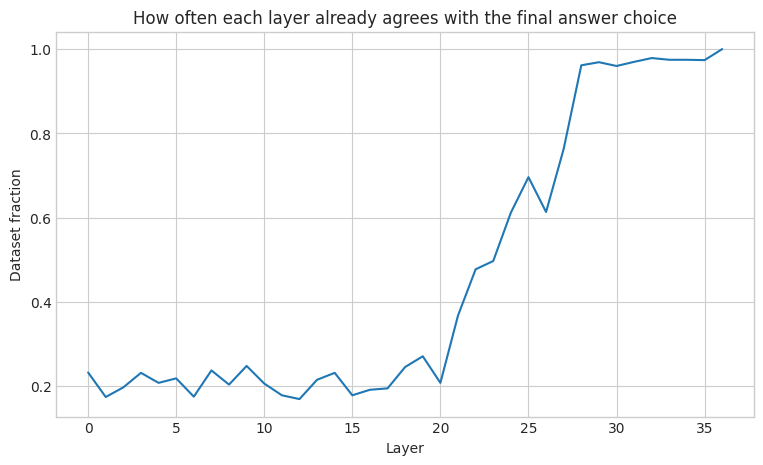

In [22]:
agreement_curve = stack_curve("answer_choice_prediction_agreement_with_final_curve")

plt.figure(figsize=(9, 5))
plt.plot(layers, agreement_curve.mean(axis=0))
plt.xlabel("Layer")
plt.ylabel("Dataset fraction")
plt.title("How often each layer already agrees with the final answer choice")
plt.show()


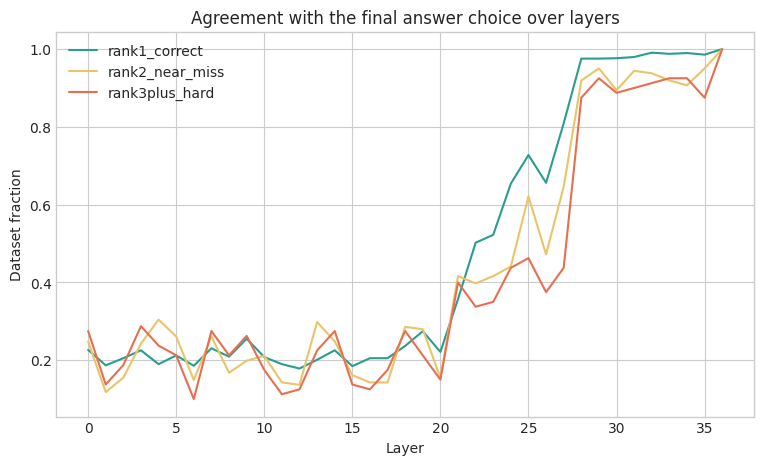

In [23]:
plt.figure(figsize=(9, 5))
for bucket in bucket_order:
    plt.plot(layers, mean_curve("answer_choice_prediction_agreement_with_final_curve", bucket), label=bucket, color=bucket_colors[bucket])
plt.xlabel("Layer")
plt.ylabel("Dataset fraction")
plt.title("Agreement with the final answer choice over layers")
plt.legend()
plt.show()


In [24]:
agreement_summary_cols = [
    "first_answer_choice_agreement_with_final_layer",
    "stable_answer_choice_agreement_with_final_layer",
]

display(
    analysis_df.groupby("answer_choice_rank_bucket")[agreement_summary_cols]
    .agg(["mean", "median", "std"])
    .round(4)
)


first_answer_choice_agreement_with_final_layer                stable_answer_choice_agreement_with_final_layer               
                                                                    mean median     std                                            mean median     std
answer_choice_rank_bucket                                                                                                                             
rank1_correct                                                     4.1857    2.0  4.5965                                         25.5265   25.0  3.0672
rank2_near_miss                                                   4.3789    4.0  5.1587                                         27.8634   27.0  3.8479
rank3plus_hard                                                    4.0125    2.0  5.2591                                         28.5750   28.0  4.3684

## Hit@k Over Layers

This plot shows how often the true answer is already inside the top-k answer choices over depth.
It is still fully inside the A-E choice space.


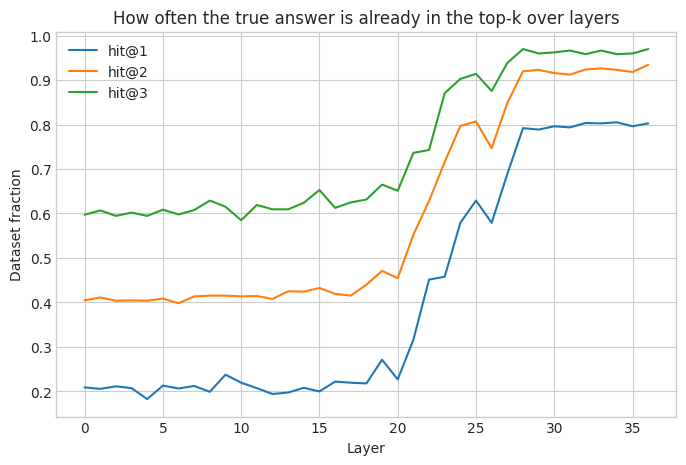

In [25]:
rank_curve = stack_curve("true_answer_rank_within_choices_curve")

hit1 = (rank_curve <= 1).mean(axis=0)
hit2 = (rank_curve <= 2).mean(axis=0)
hit3 = (rank_curve <= 3).mean(axis=0)

plt.figure(figsize=(8, 5))
plt.plot(layers, hit1, label="hit@1")
plt.plot(layers, hit2, label="hit@2")
plt.plot(layers, hit3, label="hit@3")
plt.xlabel("Layer")
plt.ylabel("Dataset fraction")
plt.title("How often the true answer is already in the top-k over layers")
plt.legend()
plt.show()
